100%|██████████| 26.4M/26.4M [00:01<00:00, 20.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 304kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.59MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.9MB/s]


LEARNING RATE OPTIMISATION TUTORIAL
Device: cuda
Learning rates: (0.0001, 0.001, 0.01, 0.1)
Seeds: (42, 123, 999)
Epochs: 15

Training with lr=0.0001 | seed=42
Epoch 01/15 | Train Loss: 2.3047 | Train Acc: 0.1000 | Test Loss: 2.3043 | Test Acc: 0.1000
Epoch 02/15 | Train Loss: 2.3041 | Train Acc: 0.1000 | Test Loss: 2.3037 | Test Acc: 0.1000
Epoch 03/15 | Train Loss: 2.3036 | Train Acc: 0.1000 | Test Loss: 2.3032 | Test Acc: 0.1000
Epoch 04/15 | Train Loss: 2.3030 | Train Acc: 0.1000 | Test Loss: 2.3026 | Test Acc: 0.1000
Epoch 05/15 | Train Loss: 2.3025 | Train Acc: 0.1000 | Test Loss: 2.3021 | Test Acc: 0.1000
Epoch 06/15 | Train Loss: 2.3019 | Train Acc: 0.1000 | Test Loss: 2.3015 | Test Acc: 0.1000
Epoch 07/15 | Train Loss: 2.3013 | Train Acc: 0.1000 | Test Loss: 2.3009 | Test Acc: 0.1000
Epoch 08/15 | Train Loss: 2.3007 | Train Acc: 0.1000 | Test Loss: 2.3004 | Test Acc: 0.1000
Epoch 09/15 | Train Loss: 2.3002 | Train Acc: 0.1000 | Test Loss: 2.2998 | Test Acc: 0.1000
Epoch 10/15 

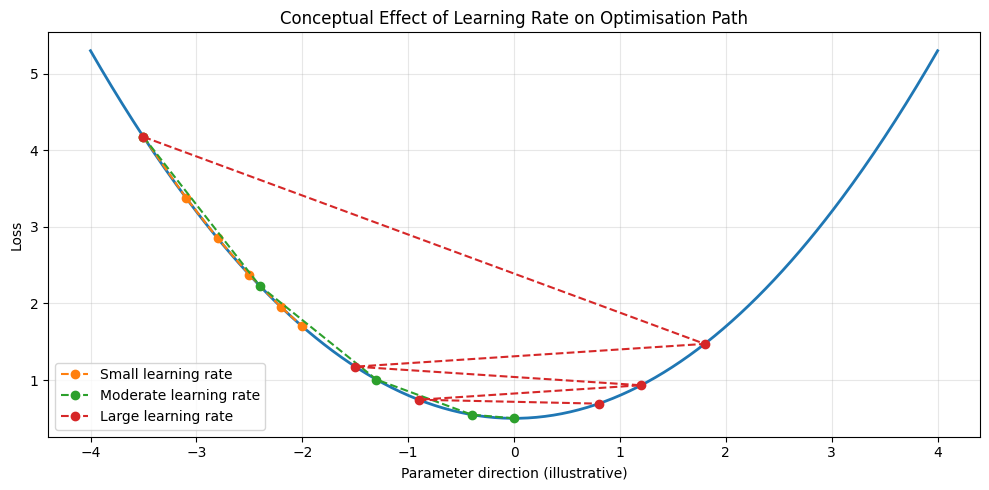

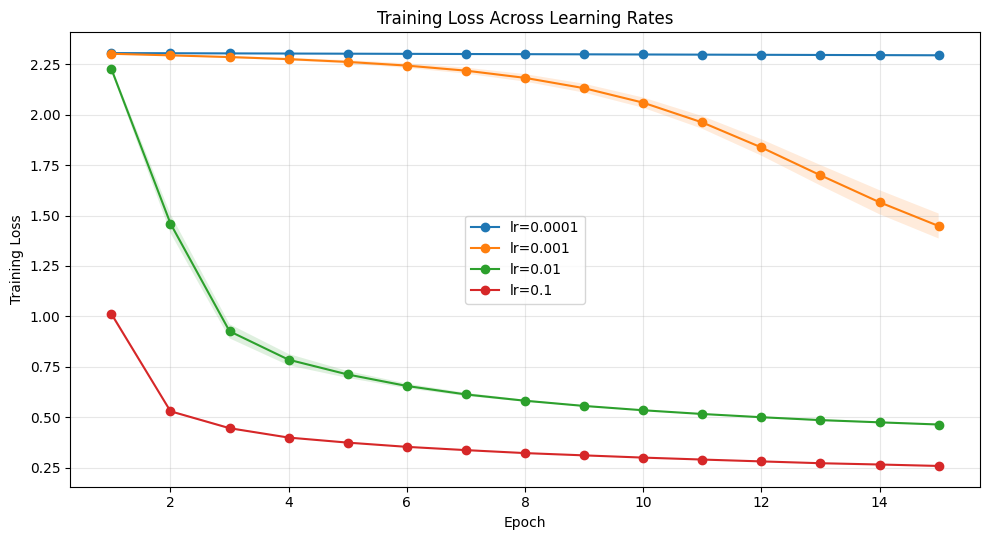

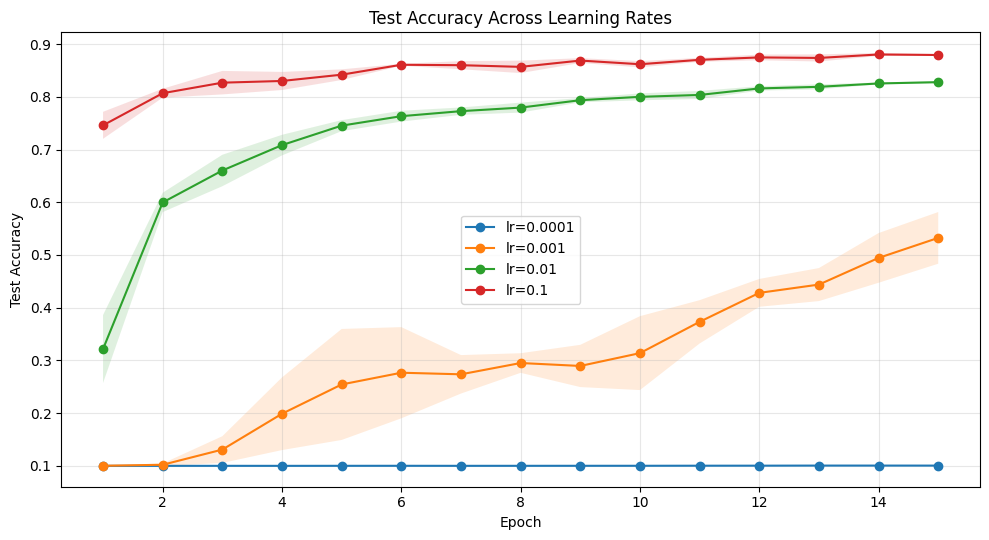

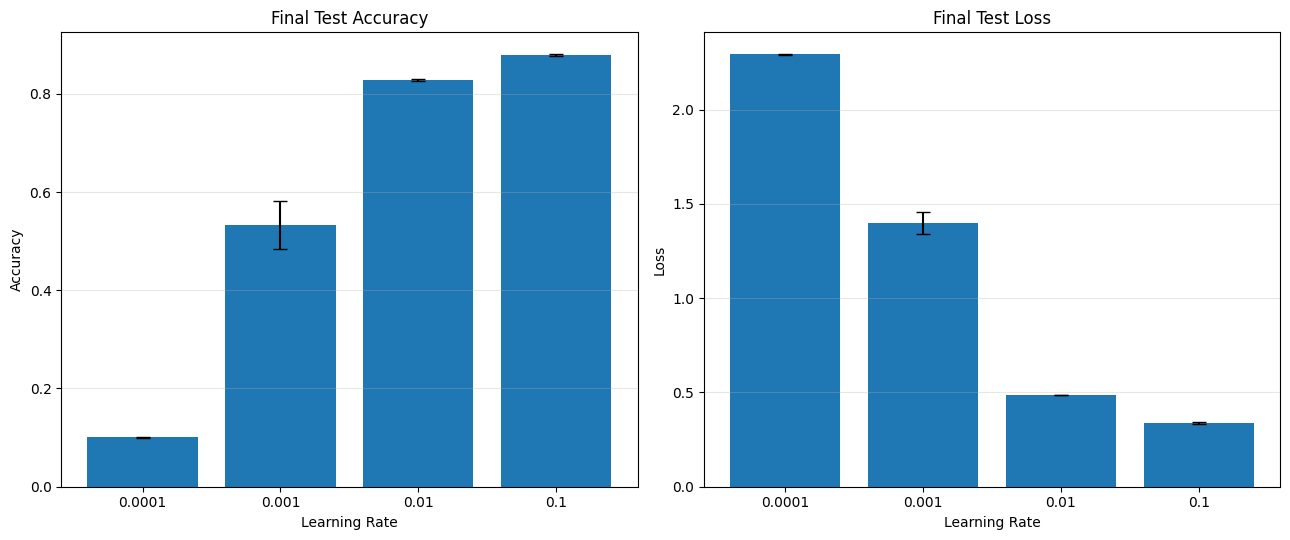

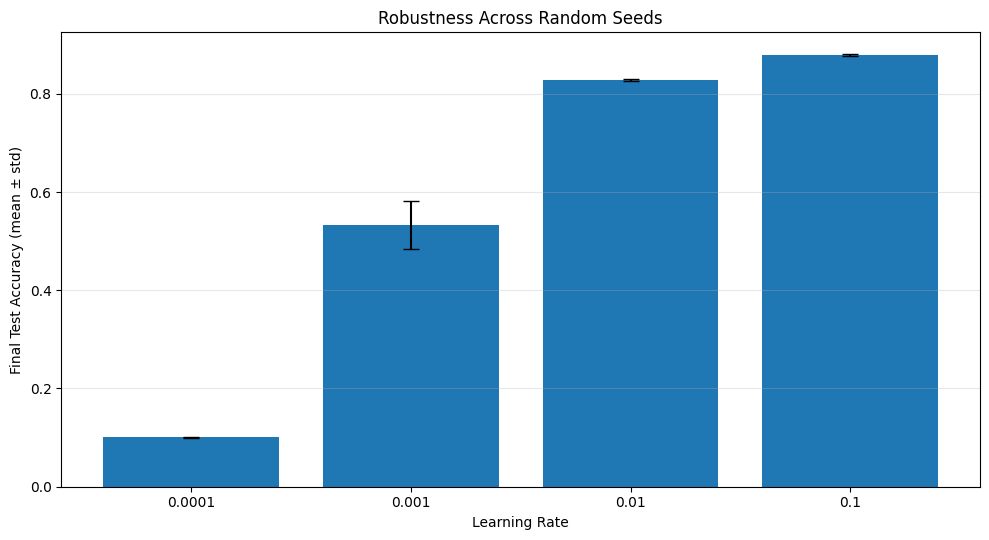


FINAL SUMMARY TABLE
 learning_rate  final_train_loss_mean  final_train_loss_std  final_test_loss_mean  final_test_loss_std  final_test_acc_mean  final_test_acc_std       stability_note
        0.0001               2.293241              0.002619              2.292845             0.002653             0.100400            0.000374          Very stable
        0.0010               1.447989              0.061803              1.399513             0.058951             0.532467            0.049019 Sensitive / unstable
        0.0100               0.465178              0.002643              0.487508             0.001572             0.827900            0.001913          Very stable
        0.1000               0.260095              0.000619              0.338953             0.005647             0.879433            0.001725          Very stable

Interpretation guide:
1. Compare training loss curves to identify slow, efficient, or unstable descent.
2. Compare test accuracy curves to see whether fa

In [1]:
# learning_rate_optimisation_tutorial.py
#
# Topic:
# "Same Network, Different Journey: How Learning Rate Changes Optimisation Dynamics in an ANN"
#
# What this script does:
# 1. Trains the same ANN on Fashion-MNIST using different learning rates
# 2. Tracks train/test loss and accuracy across epochs
# 3. Repeats each learning rate across multiple random seeds
# 4. Generates teaching-friendly figures
# 5. Prints a compact final summary for report writing
#
# Output figures:
#   figure_1_learning_rate_concept.png
#   figure_2_train_loss_curves.png
#   figure_3_test_accuracy_curves.png
#   figure_4_final_metrics.png
#   figure_5_seed_robustness.png   (optional but generated here)
#
# Suggested packages:
#   pip install torch torchvision numpy matplotlib pandas
#
# Run:
#   python learning_rate_optimisation_tutorial.py

import os
import math
import copy
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms


# ============================================================
# 1. Configuration
# ============================================================

@dataclass
class Config:
    seed: int = 42
    data_dir: str = "./data"
    output_dir: str = "./outputs_lr"

    # Training setup
    batch_size: int = 128
    epochs: int = 15

    # Learning rates to compare
    learning_rates: tuple = (1e-4, 1e-3, 1e-2, 1e-1)

    # Multiple seeds make the topic stronger:
    # they show robustness, not just one lucky run.
    seeds: tuple = (42, 123, 999)

    # Plot previews while running locally
    show_plots: bool = True

    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


CFG = Config()
os.makedirs(CFG.output_dir, exist_ok=True)


# ============================================================
# 2. Reproducibility helpers
# ============================================================

def set_seed(seed: int) -> None:
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ============================================================
# 3. Dataset
# ============================================================

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.FashionMNIST(
    root=CFG.data_dir,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root=CFG.data_dir,
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# 4. Model definition
# ============================================================

class MLP(nn.Module):
    """
    A simple ANN used for controlled optimisation experiments.

    We keep the architecture fixed and only change the learning rate.
    That way, any differences in training behaviour can be attributed
    primarily to the learning rate itself.
    """
    def __init__(self, input_dim=784, hidden_dims=(256, 128, 64), num_classes=10):
        super().__init__()
        h1, h2, h3 = hidden_dims

        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Linear(h3, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


# ============================================================
# 5. Training / evaluation functions
# ============================================================

def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    """
    Run one training or evaluation epoch.

    Why we record both loss and accuracy:
    - Loss tells us about optimisation progress and stability
    - Accuracy tells us how that progress translates into prediction quality
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


def train_single_run(learning_rate, seed):
    """
    Train one model for one learning rate and one seed.

    Keeping everything else fixed allows a clean comparison:
    same data, same architecture, same epochs, same batch size,
    same optimizer type — only the learning rate changes.
    """
    set_seed(seed)

    # Data loaders should be recreated after setting the seed so
    # shuffle order is reproducible for each run.
    train_loader = DataLoader(
        train_dataset,
        batch_size=CFG.batch_size,
        shuffle=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=CFG.batch_size,
        shuffle=False
    )

    model = MLP().to(CFG.device)
    criterion = nn.CrossEntropyLoss()

    # Plain SGD makes learning-rate effects conceptually clearer than Adam
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    print(f"\nTraining with lr={learning_rate} | seed={seed}")

    for epoch in range(1, CFG.epochs + 1):
        train_loss, train_acc = run_epoch(
            model, train_loader, criterion, optimizer=optimizer, device=CFG.device
        )
        test_loss, test_acc = run_epoch(
            model, test_loader, criterion, optimizer=None, device=CFG.device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch:02d}/{CFG.epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
        )

    return history


# ============================================================
# 6. Aggregate results across seeds
# ============================================================

def mean_std_curves(curve_list):
    """
    Given a list of equal-length curves, return mean and std arrays.
    """
    arr = np.array(curve_list)
    return arr.mean(axis=0), arr.std(axis=0)


def aggregate_results(all_results):
    """
    all_results format:
    {
        lr: {
            seed: {
                "train_loss": [...],
                "train_acc": [...],
                "test_loss": [...],
                "test_acc": [...],
            }
        }
    }

    Returns summary stats for plotting and final comparison.
    """
    aggregated = {}

    for lr, seed_runs in all_results.items():
        aggregated[lr] = {}

        for metric in ["train_loss", "train_acc", "test_loss", "test_acc"]:
            curves = [seed_runs[s][metric] for s in seed_runs]
            mean_curve, std_curve = mean_std_curves(curves)
            aggregated[lr][metric + "_mean"] = mean_curve
            aggregated[lr][metric + "_std"] = std_curve

        # Final epoch summaries across seeds
        aggregated[lr]["final_train_loss_mean"] = np.mean(
            [seed_runs[s]["train_loss"][-1] for s in seed_runs]
        )
        aggregated[lr]["final_train_loss_std"] = np.std(
            [seed_runs[s]["train_loss"][-1] for s in seed_runs]
        )

        aggregated[lr]["final_test_loss_mean"] = np.mean(
            [seed_runs[s]["test_loss"][-1] for s in seed_runs]
        )
        aggregated[lr]["final_test_loss_std"] = np.std(
            [seed_runs[s]["test_loss"][-1] for s in seed_runs]
        )

        aggregated[lr]["final_test_acc_mean"] = np.mean(
            [seed_runs[s]["test_acc"][-1] for s in seed_runs]
        )
        aggregated[lr]["final_test_acc_std"] = np.std(
            [seed_runs[s]["test_acc"][-1] for s in seed_runs]
        )

    return aggregated


# ============================================================
# 7. Figure 1: Conceptual learning-rate figure
# ============================================================

def plot_conceptual_learning_rate_figure(output_path):
    """
    A simple teaching figure to explain the concept:
    small learning rate -> tiny steps
    moderate learning rate -> efficient descent
    large learning rate -> unstable jumps / overshooting
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    # Simple bowl-shaped curve
    x = np.linspace(-4, 4, 400)
    y = 0.3 * x**2 + 0.5
    ax.plot(x, y, linewidth=2)

    # Small-step path
    small_x = np.array([-3.5, -3.1, -2.8, -2.5, -2.2, -2.0])
    small_y = 0.3 * small_x**2 + 0.5
    ax.plot(small_x, small_y, marker="o", linestyle="--", label="Small learning rate")

    # Moderate-step path
    mid_x = np.array([-3.5, -2.4, -1.3, -0.4, 0.0])
    mid_y = 0.3 * mid_x**2 + 0.5
    ax.plot(mid_x, mid_y, marker="o", linestyle="--", label="Moderate learning rate")

    # Large-step path
    large_x = np.array([-3.5, 1.8, -1.5, 1.2, -0.9, 0.8])
    large_y = 0.3 * large_x**2 + 0.5
    ax.plot(large_x, large_y, marker="o", linestyle="--", label="Large learning rate")

    ax.set_title("Conceptual Effect of Learning Rate on Optimisation Path")
    ax.set_xlabel("Parameter direction (illustrative)")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    if CFG.show_plots:
        plt.show()
    plt.close(fig)


# ============================================================
# 8. Figure 2: Training loss curves
# ============================================================

def plot_train_loss_curves(aggregated, output_path):
    """
    Training loss is central for this topic because learning rate
    is fundamentally an optimisation variable.
    """
    fig, ax = plt.subplots(figsize=(10, 5.5))
    epochs = np.arange(1, CFG.epochs + 1)

    for lr in CFG.learning_rates:
        mean_curve = aggregated[lr]["train_loss_mean"]
        std_curve = aggregated[lr]["train_loss_std"]

        ax.plot(epochs, mean_curve, marker="o", label=f"lr={lr}")
        ax.fill_between(
            epochs,
            mean_curve - std_curve,
            mean_curve + std_curve,
            alpha=0.15
        )

    ax.set_title("Training Loss Across Learning Rates")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    if CFG.show_plots:
        plt.show()
    plt.close(fig)


# ============================================================
# 9. Figure 3: Test accuracy curves
# ============================================================

def plot_test_accuracy_curves(aggregated, output_path):
    """
    Test accuracy allows us to ask a deeper question:
    does faster optimisation also mean better generalisation?
    """
    fig, ax = plt.subplots(figsize=(10, 5.5))
    epochs = np.arange(1, CFG.epochs + 1)

    for lr in CFG.learning_rates:
        mean_curve = aggregated[lr]["test_acc_mean"]
        std_curve = aggregated[lr]["test_acc_std"]

        ax.plot(epochs, mean_curve, marker="o", label=f"lr={lr}")
        ax.fill_between(
            epochs,
            mean_curve - std_curve,
            mean_curve + std_curve,
            alpha=0.15
        )

    ax.set_title("Test Accuracy Across Learning Rates")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Test Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    if CFG.show_plots:
        plt.show()
    plt.close(fig)


# ============================================================
# 10. Figure 4: Final metrics summary
# ============================================================

def stability_label(final_train_loss_std, final_test_acc_std):
    """
    A simple heuristic label for report-writing convenience.
    This is not a scientific metric; it is only a compact summary.
    """
    if final_train_loss_std < 0.01 and final_test_acc_std < 0.005:
        return "Very stable"
    elif final_train_loss_std < 0.03 and final_test_acc_std < 0.01:
        return "Reasonably stable"
    else:
        return "Sensitive / unstable"


def build_summary_table(aggregated):
    rows = []
    for lr in CFG.learning_rates:
        rows.append({
            "learning_rate": lr,
            "final_train_loss_mean": aggregated[lr]["final_train_loss_mean"],
            "final_train_loss_std": aggregated[lr]["final_train_loss_std"],
            "final_test_loss_mean": aggregated[lr]["final_test_loss_mean"],
            "final_test_loss_std": aggregated[lr]["final_test_loss_std"],
            "final_test_acc_mean": aggregated[lr]["final_test_acc_mean"],
            "final_test_acc_std": aggregated[lr]["final_test_acc_std"],
            "stability_note": stability_label(
                aggregated[lr]["final_train_loss_std"],
                aggregated[lr]["final_test_acc_std"]
            )
        })
    return pd.DataFrame(rows)


def plot_final_metrics(summary_df, output_path):
    """
    A compact final comparison figure focused on test accuracy and test loss.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    x_labels = [str(lr) for lr in summary_df["learning_rate"]]

    # Final test accuracy
    axes[0].bar(
        x_labels,
        summary_df["final_test_acc_mean"],
        yerr=summary_df["final_test_acc_std"],
        capsize=5
    )
    axes[0].set_title("Final Test Accuracy")
    axes[0].set_xlabel("Learning Rate")
    axes[0].set_ylabel("Accuracy")
    axes[0].grid(True, axis="y", alpha=0.3)

    # Final test loss
    axes[1].bar(
        x_labels,
        summary_df["final_test_loss_mean"],
        yerr=summary_df["final_test_loss_std"],
        capsize=5
    )
    axes[1].set_title("Final Test Loss")
    axes[1].set_xlabel("Learning Rate")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    if CFG.show_plots:
        plt.show()
    plt.close(fig)


# ============================================================
# 11. Figure 5: Seed robustness
# ============================================================

def plot_seed_robustness(summary_df, output_path):
    """
    Shows whether some learning rates are more reliable across random seeds.
    That supports the claim that learning rate can affect robustness too.
    """
    fig, ax = plt.subplots(figsize=(10, 5.5))

    x = np.arange(len(summary_df))
    means = summary_df["final_test_acc_mean"].values
    stds = summary_df["final_test_acc_std"].values
    labels = [str(lr) for lr in summary_df["learning_rate"]]

    ax.bar(x, means, yerr=stds, capsize=6)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel("Learning Rate")
    ax.set_ylabel("Final Test Accuracy (mean ± std)")
    ax.set_title("Robustness Across Random Seeds")
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    if CFG.show_plots:
        plt.show()
    plt.close(fig)


# ============================================================
# 12. Run all experiments
# ============================================================

def main():
    print("=" * 80)
    print("LEARNING RATE OPTIMISATION TUTORIAL")
    print("=" * 80)
    print(f"Device: {CFG.device}")
    print(f"Learning rates: {CFG.learning_rates}")
    print(f"Seeds: {CFG.seeds}")
    print(f"Epochs: {CFG.epochs}")
    print("=" * 80)

    # Store all runs
    all_results = {
        lr: {} for lr in CFG.learning_rates
    }

    # Train one run per (learning rate, seed)
    for lr in CFG.learning_rates:
        for seed in CFG.seeds:
            history = train_single_run(learning_rate=lr, seed=seed)
            all_results[lr][seed] = history

    # Aggregate across seeds
    aggregated = aggregate_results(all_results)
    summary_df = build_summary_table(aggregated)

    # Save summary table
    summary_csv_path = os.path.join(CFG.output_dir, "final_summary.csv")
    summary_df.to_csv(summary_csv_path, index=False)

    # Create figures
    plot_conceptual_learning_rate_figure(
        os.path.join(CFG.output_dir, "figure_1_learning_rate_concept.png")
    )
    plot_train_loss_curves(
        aggregated,
        os.path.join(CFG.output_dir, "figure_2_train_loss_curves.png")
    )
    plot_test_accuracy_curves(
        aggregated,
        os.path.join(CFG.output_dir, "figure_3_test_accuracy_curves.png")
    )
    plot_final_metrics(
        summary_df,
        os.path.join(CFG.output_dir, "figure_4_final_metrics.png")
    )
    plot_seed_robustness(
        summary_df,
        os.path.join(CFG.output_dir, "figure_5_seed_robustness.png")
    )

    # Print final summary for report writing
    print("\n" + "=" * 80)
    print("FINAL SUMMARY TABLE")
    print("=" * 80)
    print(summary_df.to_string(index=False))

    print("\nInterpretation guide:")
    print("1. Compare training loss curves to identify slow, efficient, or unstable descent.")
    print("2. Compare test accuracy curves to see whether faster optimisation leads to better generalisation.")
    print("3. Use final test loss and final test accuracy together; one metric alone is not enough.")
    print("4. Use the seed-robustness figure to discuss whether some learning rates are sensitive to initialization.")
    print("5. Focus your report on optimisation behaviour, not just which learning rate 'won'.")

    print("\nSaved files:")
    for name in [
        "figure_1_learning_rate_concept.png",
        "figure_2_train_loss_curves.png",
        "figure_3_test_accuracy_curves.png",
        "figure_4_final_metrics.png",
        "figure_5_seed_robustness.png",
        "final_summary.csv"
    ]:
        print("-", os.path.join(CFG.output_dir, name))


if __name__ == "__main__":
    main()